# 03. Klasyfikacja: progi liczbowe i granice decyzyjne

Cel: przejść od cech 0/1 do cech liczbowych. Drzewo musi samo znaleźć pytania typu:

```text
czy projekt_pkt <= 57.5?
czy obecnosc_pct <= 69.5?
```

Dane są fikcyjne i dydaktyczne: każdy wiersz opisuje studenta na laboratorium.

## Jak ten notebook rozwija poprzednie?

W notebookach 01–02 cechy były głównie binarne, np.:

```text
cieplo = 0/1
weekend = 0/1
krotka_kolejka = 0/1
```

Wtedy pytanie drzewa było proste:

```text
czy cecha == 1?
```

Tutaj przechodzimy do cech liczbowych, np.:

```text
obecnosc_pct = 72
zadania_pkt = 58
projekt_pkt = 63
```

Drzewo musi więc samo znaleźć próg:

```text
czy projekt_pkt <= 57.5?
```

To jest bardzo ważna kontynuacja: **uczymy się, skąd biorą się granice typu `3.5`, `57.5`, `69.5` w narysowanym drzewie.**

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay, classification_report

BASE = Path.cwd()
for candidate in [BASE, BASE.parent, Path("/mnt/data/drzewa_decyzyjne_dydaktyka")]:
    if (candidate / "data" / "02_zaliczenie_lab.csv").exists():
        BASE = candidate
        break
else:
    BASE = Path.cwd()

csv_path = BASE / "data" / "02_zaliczenie_lab.csv"

if csv_path.exists():
    df = pd.read_csv(csv_path)
else:
    # Fallback dydaktyczny: fikcyjni studenci i decyzja zaliczone/do_poprawy.
    rng = np.random.default_rng(42)
    n = 140
    zadania_pkt = np.clip(rng.normal(60, 18, n), 0, 100).round(1)
    projekt_pkt = np.clip(0.45 * zadania_pkt + rng.normal(35, 18, n), 0, 100).round(1)
    quiz_pkt = np.clip(rng.normal(58, 20, n), 0, 100).round(1)
    obecnosc_pct = np.clip(rng.normal(78, 13, n), 40, 100).round(1)

    score = (
        0.30 * zadania_pkt
        + 0.35 * projekt_pkt
        + 0.15 * quiz_pkt
        + 0.20 * obecnosc_pct
        + rng.normal(0, 8, n)
    )
    zaliczenie = np.where(score >= 61, "zaliczone", "do_poprawy")

    df = pd.DataFrame({
        "student_id": range(1, n + 1),
        "obecnosc_pct": obecnosc_pct,
        "zadania_pkt": zadania_pkt,
        "projekt_pkt": projekt_pkt,
        "quiz_pkt": quiz_pkt,
        "zaliczenie": zaliczenie,
    })

df.head()


,student_id,obecnosc_pct,zadania_pkt,projekt_pkt,quiz_pkt,zaliczenie
0,1,79.2,65.5,71.9,67.6,zaliczone
1,2,67.1,41.3,35.8,23.1,do_poprawy
2,3,70.3,73.5,29.7,76.5,do_poprawy
3,4,58.8,76.9,74.4,67.1,zaliczone
4,5,66.5,24.9,31.6,35.8,do_poprawy


In [4]:
df.shape

(140, 6)

In [5]:
df

,student_id,obecnosc_pct,zadania_pkt,projekt_pkt,quiz_pkt,zaliczenie
0,1,79.2,65.5,71.9,67.6,zaliczone
1,2,67.1,41.3,35.8,23.1,do_poprawy
2,3,70.3,73.5,29.7,76.5,do_poprawy
3,4,58.8,76.9,74.4,67.1,zaliczone
4,5,66.5,24.9,31.6,35.8,do_poprawy
...,...,...,...,...,...,...
135,136,74.0,41.7,60.7,62.0,do_poprawy
136,137,68.2,65.6,50.8,79.8,do_poprawy
137,138,64.6,75.1,48.8,84.6,do_poprawy
138,139,61.8,95.9,99.6,56.6,zaliczone


In [2]:
df["zaliczenie"].value_counts(normalize=True).rename("proporcja")

zaliczone     0.585714
do_poprawy    0.414286
Name: proporcja, dtype: float64

# 1. Pierwsze spojrzenie na dane

Zanim uczymy model, sprawdzamy proste zależności. Drzewa dobrze radzą sobie z progami, więc wykres punktowy jest bardzo pomocny.

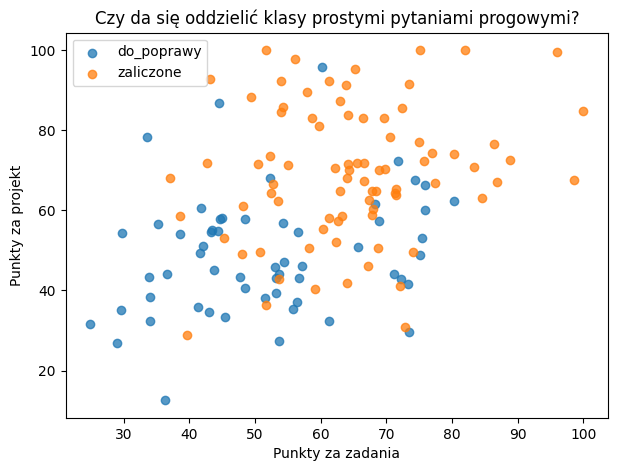

In [3]:
plt.figure(figsize=(7, 5))
for label, part in df.groupby("zaliczenie"):
    plt.scatter(part["zadania_pkt"], part["projekt_pkt"], label=label, alpha=0.75)
plt.xlabel("Punkty za zadania")
plt.ylabel("Punkty za projekt")
plt.title("Czy da się oddzielić klasy prostymi pytaniami progowymi?")
plt.legend()
plt.show()

# 2. Jak drzewo wybiera próg?

Dla cechy liczbowej drzewo sortuje wartości i rozważa progi między sąsiednimi wartościami.

Poniżej robimy uproszczoną wersję ręcznie dla jednej cechy.

### Skąd biorą się kandydaci na progi?

Dla cechy liczbowej drzewo nie sprawdza wszystkich liczb rzeczywistych.  
Zamiast tego sortuje wartości danej cechy i sprawdza progi pomiędzy sąsiednimi wartościami.

Przykład:

```text
wartości cechy: 40, 42, 50, 60
kandydaci:      41, 46, 55
```

Dlatego na wykresach i w drzewach często widzimy progi z końcówką `.5`.

Jeżeli w danych są wartości:

```text
57 i 58
```

to naturalnym kandydatem jest:

```text
57.5
```

Taki próg oznacza:

```text
lewa gałąź:  wartość <= 57.5
prawa gałąź: wartość > 57.5
```

In [12]:
def gini(labels):
    probs = labels.value_counts(normalize=True)
    return 1 - np.sum(probs ** 2)

def threshold_table(data, feature, target="zaliczenie"):
    values = np.sort(data[feature].unique())
    thresholds = (values[:-1] + values[1:]) / 2
    rows = []
    parent = gini(data[target])

    for t in thresholds:
        left = data[data[feature] <= t]
        right = data[data[feature] > t]
        if len(left) == 0 or len(right) == 0:
            continue
        weighted = len(left)/len(data)*gini(left[target]) + len(right)/len(data)*gini(right[target])
        rows.append({
            "cecha": feature,
            "prog": round(t, 2),
            "gini_po_podziale": weighted,
            "zysk_gini": parent - weighted,
            "lewa_liczba": len(left),
            "prawa_liczba": len(right)
        })
    return pd.DataFrame(rows).sort_values("gini_po_podziale")

threshold_table(df, "projekt_pkt").head(10)

,cecha,prog,gini_po_podziale,zysk_gini,lewa_liczba,prawa_liczba
56,projekt_pkt,58.15,0.312747,0.172559,64,76
57,projekt_pkt,58.40,0.320029,0.165277,65,75
55,projekt_pkt,58.00,0.322037,0.163269,63,77
67,projekt_pkt,62.45,0.322374,0.162932,75,65
65,projekt_pkt,62.00,0.325689,0.159618,73,67
58,projekt_pkt,58.65,0.327074,0.158232,66,74
63,projekt_pkt,60.85,0.328703,0.156603,71,69
68,projekt_pkt,62.75,0.328724,0.156582,76,64
54,projekt_pkt,57.85,0.331029,0.154277,62,78
61,projekt_pkt,60.25,0.331432,0.153874,69,71


**Uwaga dydaktyczna:** w tej sekcji liczymy kandydatów na progi na całym zbiorze tylko po to, żeby zrozumieć mechanizm. W prawdziwym procesie ML progi są wybierane na danych treningowych, a zbiór testowy zostaje odłożony do oceny modelu.

To jest ten sam pomysł co w pierwszym notebooku, tylko pytanie brzmi nie `cecha == 1`, ale `cecha <= próg`.

Najpierw ręcznie pokazujemy, jak drzewo szuka progu dla jednej cechy na całym zbiorze danych.

Prawdziwe drzewo działa jednak na danych treningowych, a nie na całym zbiorze.
Dodatkowo po pierwszym podziale każde kolejne pytanie jest wybierane już tylko dla fragmentu danych,
który trafił do danej gałęzi.

Dlatego progi z tabeli ręcznej i progi wypisane przez wytrenowane drzewo nie muszą być identyczne.
Ważny jest mechanizm: drzewo sortuje wartości, sprawdza progi między wartościami i wybiera ten,
który najbardziej zmniejsza nieczystość Gini.

Dla każdego kandydata na próg drzewo wykonuje próbny podział danych.

Przykład:

Jeśli próg wynosi `58.15`, to tworzymy dwie grupy:

- lewa gałąź: `projekt_pkt <= 58.15`
- prawa gałąź: `projekt_pkt > 58.15`

W tabeli widzimy, że wtedy:

- po lewej stronie są 64 obserwacje,
- po prawej stronie są 76 obserwacje.

Następnie liczymy nieczystość Gini osobno dla lewej i prawej strony, a potem bierzemy średnią ważoną:

$$
Gini_{split}
=
\frac{n_L}{n}Gini_L
+
\frac{n_R}{n}Gini_R
$$

Dla progu `58.15` otrzymujemy:

$$
Gini_{split} = 0.312747
$$

Zysk Gini to różnica między nieczystością przed podziałem i po podziale:

$$
Gain =
Gini_{parent} - Gini_{split}
$$

Tutaj:

$$
Gain = 0.485306 - 0.312747 = 0.172559
$$

Dlatego próg `58.15` jest najlepszy w tej tabeli: daje najmniejsze `gini_po_podziale` i największy `zysk_gini`.

## Jak dokładnie liczymy Gini dla konkretnego progu?

Weźmy najlepszy próg z tabeli:

```text
projekt_pkt <= 58.15
```

Tabela mówi:

```text
lewa_liczba  = 64
prawa_liczba = 76
```

Po podziale klas mamy:

### Lewa gałąź

```text
do_poprawy -> 47
zaliczone  -> 17
```

Czyli:

$$
p_{\text{do poprawy}} = \frac{47}{64}
$$

$$
p_{\text{zaliczone}} = \frac{17}{64}
$$
Liczymy:

$$
Gini_L =
1 - \left(\frac{47}{64}\right)^2
  - \left(\frac{17}{64}\right)^2
$$

$$
Gini_L \approx 0.390137
$$

---

### Prawa gałąź

```text
zaliczone  -> 65
do_poprawy -> 11
```

Czyli:

$$
p_{\text{zaliczone}} = \frac{65}{76}
$$

$$
p_{\text{do poprawy}} = \frac{11}{76}
$$


Liczymy:

$$
Gini_R =
1 - \left(\frac{65}{76}\right)^2
  - \left(\frac{11}{76}\right)^2
$$

$$
Gini_R \approx 0.247576
$$

---

## Średnia ważona

$$
Gini_{split}
=
\frac{64}{140} \cdot 0.390137
+
\frac{76}{140} \cdot 0.247576
$$

$$
Gini_{split}
\approx 0.312747
$$

Dokładnie tę wartość widzimy w tabeli.

## Interpretacja

- małe Gini = bardziej uporządkowane grupy,
- duże Gini = klasy są mocno wymieszane.

Drzewo wybiera taki próg,
który daje najmniejsze `Gini_split`.

W praktyce oznacza to:

- po jednej stronie głównie jedna klasa,
- po drugiej stronie głównie druga klasa

## Uwaga: Gini i entropia

W drzewach klasyfikacyjnych jakość podziału można mierzyć różnymi kryteriami.

Najczęściej używane są:

- `gini` — mierzy wymieszanie klas,
- `entropy` — mierzy niepewność informacyjną.

Oba kryteria szukają podobnej rzeczy:

```text
dobry split = po podziale klasy są bardziej uporządkowane

In [10]:
t = 58.15

left = df[df["projekt_pkt"] <= t]
right = df[df["projekt_pkt"] > t]
print(len(left))
print(len(right))
print(left["zaliczenie"].value_counts())
print(right["zaliczenie"].value_counts())

64
76
do_poprawy    47
zaliczone     17
Name: zaliczenie, dtype: int64
zaliczone     65
do_poprawy    11
Name: zaliczenie, dtype: int64


In [13]:
t = 58.15

left = df[df["projekt_pkt"] <= t]
right = df[df["projekt_pkt"] > t]

print("Lewa liczba:", len(left))
print("Prawa liczba:", len(right))

print("\nLEFT:")
print(left["zaliczenie"].value_counts())

print("\nRIGHT:")
print(right["zaliczenie"].value_counts())

gini_left = gini(left["zaliczenie"])
gini_right = gini(right["zaliczenie"])

weighted = (
    len(left) / len(df) * gini_left
    +
    len(right) / len(df) * gini_right
)

print("\nGini LEFT:", round(gini_left, 6))
print("Gini RIGHT:", round(gini_right, 6))
print("Gini split:", round(weighted, 6))

Lewa liczba: 64
Prawa liczba: 76

LEFT:
do_poprawy    47
zaliczone     17
Name: zaliczenie, dtype: int64

RIGHT:
zaliczone     65
do_poprawy    11
Name: zaliczenie, dtype: int64

Gini LEFT: 0.390137
Gini RIGHT: 0.247576
Gini split: 0.312747


### Lewa gałąź

$$
Gini_L =
1 - \left(\frac{47}{64}\right)^2 - \left(\frac{17}{64}\right)^2
$$

$$
Gini_L \approx 0.390137
$$

### Prawa gałąź

$$
Gini_R =
1 - \left(\frac{65}{76}\right)^2 - \left(\frac{11}{76}\right)^2
$$

$$
Gini_R \approx 0.247576
$$

### Gini po podziale

$$
Gini_{split}
=
\frac{64}{140} \cdot 0.390137
+
\frac{76}{140} \cdot 0.247576
$$

$$
Gini_{split}
\approx 0.312747
$$

In [18]:
df

,student_id,obecnosc_pct,zadania_pkt,projekt_pkt,quiz_pkt,zaliczenie
0,1,79.2,65.5,71.9,67.6,zaliczone
1,2,67.1,41.3,35.8,23.1,do_poprawy
2,3,70.3,73.5,29.7,76.5,do_poprawy
3,4,58.8,76.9,74.4,67.1,zaliczone
4,5,66.5,24.9,31.6,35.8,do_poprawy
...,...,...,...,...,...,...
135,136,74.0,41.7,60.7,62.0,do_poprawy
136,137,68.2,65.6,50.8,79.8,do_poprawy
137,138,64.6,75.1,48.8,84.6,do_poprawy
138,139,61.8,95.9,99.6,56.6,zaliczone


## Porównanie najlepszych progów dla różnych cech

Dla każdej cechy:

1. generujemy wszystkie możliwe progi,
2. liczymy Gini po podziale,
3. wybieramy najlepszy próg (`head(1)`),
4. porównujemy cechy między sobą.

Dzięki temu możemy zobaczyć,
która cecha daje najbardziej uporządkowany podział danych.

In [ ]:
"""
features_numeric = [
    "obecnosc_pct",
    "zadania_pkt",
    "projekt_pkt",
    "quiz_pkt"
]
for f in features_numeric:
    threshold_table(df, f).head(1)
"""

In [20]:

features_numeric = [
    "obecnosc_pct",
    "zadania_pkt",
    "projekt_pkt",
    "quiz_pkt"
]
for f in features_numeric:
    print(threshold_table(df, f).head(1))

          cecha   prog  gini_po_podziale  zysk_gini  lewa_liczba  prawa_liczba
0  obecnosc_pct  43.45           0.48037   0.004936            1           139
          cecha   prog  gini_po_podziale  zysk_gini  lewa_liczba  prawa_liczba
30  zadania_pkt  47.85          0.391336    0.09397           32           108
          cecha   prog  gini_po_podziale  zysk_gini  lewa_liczba  prawa_liczba
56  projekt_pkt  58.15          0.312747   0.172559           64            76
       cecha   prog  gini_po_podziale  zysk_gini  lewa_liczba  prawa_liczba
55  quiz_pkt  56.25           0.40322   0.082086           58            82


In [14]:
# Porównajmy najlepsze progi dla kilku cech.
features_numeric = ["obecnosc_pct", "zadania_pkt", "projekt_pkt", "quiz_pkt"]
best = pd.concat([threshold_table(df, f).head(1) for f in features_numeric])
best.sort_values("gini_po_podziale")

,cecha,prog,gini_po_podziale,zysk_gini,lewa_liczba,prawa_liczba
56,projekt_pkt,58.15,0.312747,0.172559,64,76
30,zadania_pkt,47.85,0.391336,0.093970,32,108
55,quiz_pkt,56.25,0.403220,0.082086,58,82
0,obecnosc_pct,43.45,0.480370,0.004936,1,139


## Mini-ćwiczenie 1: która cecha daje najlepszy pojedynczy próg?

Zmień nazwę cechy w funkcji:

```python
threshold_table(df, "projekt_pkt").head(5)

In [33]:
#threshold_table(df, "quiz_pkt").head(5)
#threshold_table(df, "projekt_pkt").head(5)
#threshold_table(df, "zadania_pkt").head(5)
#threshold_table(df, "obecnosc_pct").head(5)

```
Wynik wykonania:


projekt_pkt  -> próg 58.15, gini_po_podziale 0.312747
zadania_pkt  -> próg 47.85, gini_po_podziale 0.391336
quiz_pkt     -> próg 56.25, gini_po_podziale 0.403220
obecnosc_pct -> próg 43.45, gini_po_podziale 0.480370
```

Najlepszy pojedynczy próg daje `projekt_pkt`, bo ma najmniejsze `gini_po_podziale`.
To znaczy, że sam wynik projektu najlepiej rozdziela klasy `zaliczone` / `do_poprawy`.

# 3. Uczenie prostego drzewa

Najpierw użyjemy tylko cech liczbowych. Dzięki temu łatwo narysować drzewo i granice decyzyjne.

## Od pojedynczego splitu do całego drzewa

W poprzedniej sekcji ręcznie:
- wybieraliśmy cechę,
- testowaliśmy progi,
- liczyliśmy Gini,
- wybieraliśmy najlepszy podział.

Prawdziwe drzewo robi dokładnie to samo,
ale automatycznie i wielokrotnie:

1. znajduje najlepszy pierwszy split,
2. dzieli dane,
3. osobno analizuje lewą gałąź,
4. osobno analizuje prawą gałąź,
5. powtarza proces rekurencyjnie.

W ten sposób powstaje całe drzewo decyzyjne.

### Co robi `model.fit(X_train, y_train)`?

Dla każdej cechy liczbowej model:

```text
1. sortuje wartości,
2. tworzy możliwe progi między sąsiednimi wartościami,
3. dla każdego progu dzieli dane na lewo/prawo,
4. liczy Gini po podziale,
5. wybiera próg z największym zyskiem,
6. powtarza proces w kolejnych węzłach.
```

Czyli model nie zna z góry progu zaliczenia.  
On znajduje go automatycznie, szukając takiego podziału, który najlepiej rozdziela klasy.

In [22]:
X = df[["obecnosc_pct", "zadania_pkt", "projekt_pkt", "quiz_pkt"]]
y = df["zaliczenie"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

model = DecisionTreeClassifier(max_depth=3, criterion="gini", random_state=42)
model.fit(X_train, y_train)

print("Accuracy train:", round(accuracy_score(y_train, model.predict(X_train)), 3))
print("Accuracy test: ", round(accuracy_score(y_test, model.predict(X_test)), 3))
print()
print(export_text(model, feature_names=list(X.columns)))

Accuracy train: 0.847
Accuracy test:  0.738

|--- projekt_pkt <= 62.70
|   |--- quiz_pkt <= 56.30
|   |   |--- quiz_pkt <= 14.95
|   |   |   |--- class: do_poprawy
|   |   |--- quiz_pkt >  14.95
|   |   |   |--- class: do_poprawy
|   |--- quiz_pkt >  56.30
|   |   |--- zadania_pkt <= 36.30
|   |   |   |--- class: do_poprawy
|   |   |--- zadania_pkt >  36.30
|   |   |   |--- class: zaliczone
|--- projekt_pkt >  62.70
|   |--- quiz_pkt <= 63.30
|   |   |--- obecnosc_pct <= 65.15
|   |   |   |--- class: do_poprawy
|   |   |--- obecnosc_pct >  65.15
|   |   |   |--- class: zaliczone
|   |--- quiz_pkt >  63.30
|   |   |--- class: zaliczone



Pierwszy wiersz drzewa:

```text
projekt_pkt <= 62.70
```

oznacza:

> Drzewo uznało, że najlepszym pierwszym pytaniem
> jest podział po `projekt_pkt`.

To jest dokładnie ten sam mechanizm,
który wcześniej liczyliśmy ręcznie.

In [23]:
print(export_text(model, feature_names=list(X.columns)))

|--- projekt_pkt <= 62.70
|   |--- quiz_pkt <= 56.30
|   |   |--- quiz_pkt <= 14.95
|   |   |   |--- class: do_poprawy
|   |   |--- quiz_pkt >  14.95
|   |   |   |--- class: do_poprawy
|   |--- quiz_pkt >  56.30
|   |   |--- zadania_pkt <= 36.30
|   |   |   |--- class: do_poprawy
|   |   |--- zadania_pkt >  36.30
|   |   |   |--- class: zaliczone
|--- projekt_pkt >  62.70
|   |--- quiz_pkt <= 63.30
|   |   |--- obecnosc_pct <= 65.15
|   |   |   |--- class: do_poprawy
|   |   |--- obecnosc_pct >  65.15
|   |   |   |--- class: zaliczone
|   |--- quiz_pkt >  63.30
|   |   |--- class: zaliczone



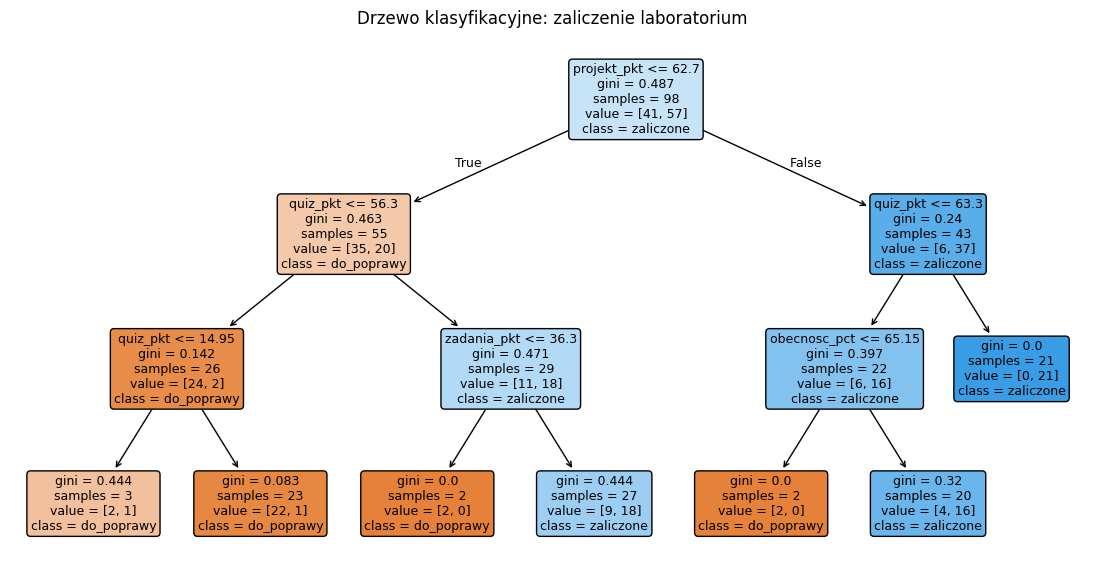

In [7]:
plt.figure(figsize=(14, 7))
plot_tree(
    model,
    feature_names=list(X.columns),
    class_names=list(model.classes_),
    filled=True,
    rounded=True,
    impurity=True,
    fontsize=9
)
plt.title("Drzewo klasyfikacyjne: zaliczenie laboratorium")
plt.show()

# 4. Macierz pomyłek

Sama trafność bywa myląca. Macierz pomyłek pokazuje, które błędy model robi najczęściej.

## Dlaczego używamy zbioru testowego?

Model uczył się tylko na danych treningowych (`X_train`, `y_train`).

Gdybyśmy oceniali go na tych samych danych,
wynik byłby zwykle zbyt optymistyczny.

Dlatego odkładamy część danych jako zbiór testowy:

- train → uczenie modelu,
- test → sprawdzenie,
  jak model działa na nowych danych.

Macierz pomyłek poniżej pokazuje błędy modelu właśnie na zbiorze testowym.

### Uwaga: data leakage

Model powinien uczyć się tylko na danych treningowych (`train`).

Gdyby informacje ze zbioru testowego „przeciekły” do treningu
(np. przy wyborze progów lub skalowaniu danych),
wyniki mogłyby być sztucznie zawyżone.

Dlatego model budujemy na `train`,
a `test` zostawiamy wyłącznie do końcowej oceny jakości.

## Dlaczego sama accuracy nie wystarcza?

Dwa modele mogą mieć podobną accuracy,
ale popełniać zupełnie inne błędy.

W wielu problemach rodzaj błędu ma ogromne znaczenie.

Przykłady:
- medycyna: przeoczenie chorego pacjenta,
- spam: oznaczenie ważnego maila jako spam,
- edukacja: przepuszczenie osoby, która nie powinna zaliczyć.

Dlatego chcemy wiedzieć nie tylko:
- ile predykcji było poprawnych,

ale również:
- jakie błędy model popełnia najczęściej.

Do tego służy macierz pomyłek.

### Jak czytać macierz pomyłek?

Macierz pomyłek pokazuje nie tylko „ile było dobrze”, ale też **jakiego typu błędy** zrobił model.

Dla klasyfikacji `zaliczone` / `do_poprawy` interesują nas szczególnie dwa błędy:

```text
model mówi: zaliczone, ale naprawdę: do_poprawy
model mówi: do_poprawy, ale naprawdę: zaliczone
```

To jest bardziej informacyjne niż sama accuracy.

# ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)
plt.title("Macierz pomyłek na zbiorze testowym")
plt.show()

print(classification_report(y_test, model.predict(X_test)))

## Co robi ten kod?

```python
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)
```

Ta funkcja:

1. bierze wytrenowany model,
2. wykonuje predykcje dla `X_test`,
3. porównuje predykcje z prawdziwymi etykietami `y_test`,
4. buduje macierz pomyłek,
5. automatycznie rysuje ją jako wykres.

W praktyce działa podobnie do:

```python
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
```

ale dodatkowo od razu tworzy wykres.

---

```python
plt.title("Macierz pomyłek na zbiorze testowym")
```

Dodaje tytuł wykresu.

---

```python
plt.show()
```

Wyświetla wykres.

---

## Co robi `classification_report`?

```python
print(classification_report(y_test, model.predict(X_test)))
```

Najpierw:

```python
model.predict(X_test)
```

tworzy predykcje modelu dla danych testowych.

Następnie:

```python
classification_report(...)
```

liczy podstawowe metryki klasyfikacji:

- precision,
- recall,
- f1-score,
- support.

dla każdej klasy osobno.

---

## Intuicja

Macierz pomyłek pokazuje:

```text
jakie błędy model popełnia
```

natomiast `classification_report` pokazuje:

```text
jak dobrze model działa liczbowo
```

dla każdej klasy.

### Wyjaśnienie Confusion Matrix: Patrz -> APPENDIX A

## Jak czytać tę macierz pomyłek?

W `sklearn`:

- wiersze (`True label`) oznaczają klasy prawdziwe,
- kolumny (`Predicted label`) oznaczają predykcje modelu.

Dla naszej klasyfikacji:

- pozytywna klasa = `zaliczone`
- negatywna klasa = `do_poprawy`

Macierz:

|                      | przewidziano: do_poprawy | przewidziano: zaliczone |
|----------------------|--------------------------|--------------------------|
| **prawda: do_poprawy** | 10 | 7 |
| **prawda: zaliczone**  | 4  | 21 |

możemy zapisać jako:

$$
\begin{bmatrix}
TN & FP \\
FN & TP
\end{bmatrix}
=
\begin{bmatrix}
10 & 7 \\
4 & 21
\end{bmatrix}
$$

---

## Interpretacja poszczególnych pól

### True Negative (TN) = 10

Model poprawnie przewidział `do_poprawy`.

```text
model: do_poprawy
prawda: do_poprawy
```

---

### False Positive (FP) = 7

Model przewidział `zaliczone`,
ale student naprawdę powinien mieć `do_poprawy`.

```text
model: zaliczone
prawda: do_poprawy
```

To jest potencjalnie „niebezpieczny” błąd,
bo model przepuścił osobę,
która nie powinna zaliczyć.

---

### False Negative (FN) = 4

Model przewidział `do_poprawy`,
ale student naprawdę zaliczył.

```text
model: do_poprawy
prawda: zaliczone
```

---

### True Positive (TP) = 21

Model poprawnie przewidział `zaliczone`.

```text
model: zaliczone
prawda: zaliczone
```

---

## Accuracy

Poprawne predykcje:

$$
TP + TN = 21 + 10 = 31
$$

Wszystkie przypadki:

$$
31 + 7 + 4 = 42
$$

Accuracy:

$$
Accuracy =
\frac{31}{42}
\approx 0.738
$$

czyli około:

```text
73.8%
```

---

## Precision dla klasy `zaliczone`

Spośród wszystkich osób,
którym model przewidział `zaliczone`:

$$
Precision =
\frac{TP}{TP + FP}
=
\frac{21}{21 + 7}
=
0.75
$$

Czyli:

```text
75% osób przewidzianych jako "zaliczone"
rzeczywiście zaliczyło.
```

---

## Recall dla klasy `zaliczone`

Spośród wszystkich osób,
które naprawdę zaliczyły:

$$
Recall =
\frac{TP}{TP + FN}
=
\frac{21}{21 + 4}
=
0.84
$$

Czyli model wykrył około:

```text
84% wszystkich osób,
które rzeczywiście zaliczyły.
```

Uwaga:
różne biblioteki i książki mogą stosować różne orientacje macierzy pomyłek.

Dlatego zawsze warto sprawdzić:
- co oznaczają wiersze,
- co oznaczają kolumny.

# 5. Granica decyzyjna w 2D

Pełne drzewo ma kilka cech, więc trudno pokazać je na płaszczyźnie. Dla wizualizacji uczymy drugie drzewo tylko na dwóch cechach: `zadania_pkt` i `projekt_pkt`.

## Jak drzewo tworzy granice decyzyjne?

W tej sekcji uczymy nowe drzewo tylko na dwóch cechach:

- `zadania_pkt`
- `projekt_pkt`

Dzięki temu możemy narysować decyzje modelu na płaszczyźnie 2D.

---

## Jak interpretować granice?

Każdy split drzewa jest pytaniem o jedną cechę, np.:

```text
zadania_pkt <= 57
```

albo:

```text
projekt_pkt <= 58
```

Na wykresie:

- pytanie o cechę z osi X daje pionową granicę,
- pytanie o cechę z osi Y daje poziomą granicę.

Dlatego drzewo tworzy prostokątne obszary decyzyjne.

---

## Intuicja geometryczna

Drzewo nie tworzy jednej globalnej prostej jak regresja logistyczna lub SVM liniowy.

Zamiast tego:

1. wykonuje pierwszy podział,
2. dzieli przestrzeń na części,
3. w każdej części wykonuje kolejne podziały,
4. tworzy coraz mniejsze prostokątne regiony.

Każdy region odpowiada jednej decyzji modelu:

- `zaliczone`
- albo `do_poprawy`

Kolor tła pokazuje,
jaką klasę model przewiduje w danym obszarze przestrzeni cech.

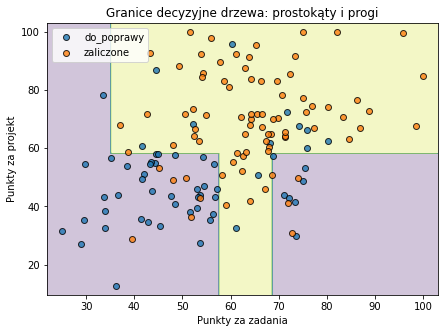

In [25]:
X2 = df[["zadania_pkt", "projekt_pkt"]]
y2 = df["zaliczenie"]

model2 = DecisionTreeClassifier(max_depth=3, random_state=42)
model2.fit(X2, y2)

x_min, x_max = X2["zadania_pkt"].min() - 3, X2["zadania_pkt"].max() + 3
y_min, y_max = X2["projekt_pkt"].min() - 3, X2["projekt_pkt"].max() + 3
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 250), np.linspace(y_min, y_max, 250))
mesh = pd.DataFrame({"zadania_pkt": xx.ravel(), "projekt_pkt": yy.ravel()})
Z = model2.predict(mesh).reshape(xx.shape)
Z_num = (Z == "zaliczone").astype(int)

plt.figure(figsize=(7, 5))
plt.contourf(xx, yy, Z_num, alpha=0.25)
for label, part in df.groupby("zaliczenie"):
    plt.scatter(part["zadania_pkt"], part["projekt_pkt"], label=label, edgecolor="k", alpha=0.8)
plt.xlabel("Punkty za zadania")
plt.ylabel("Punkty za projekt")
plt.title("Granice decyzyjne drzewa: prostokąty i progi")
plt.legend()
plt.show()

## Uwaga dydaktyczna

W tej sekcji celowo uczymy model na całym zbiorze danych.

Nie robimy tutaj podziału train/test,
ponieważ celem nie jest uczciwa ocena jakości modelu,
ale wizualizacja granic decyzyjnych drzewa.

Chcemy po prostu zobaczyć,
jak drzewo dzieli przestrzeń cech na prostokątne regiony.

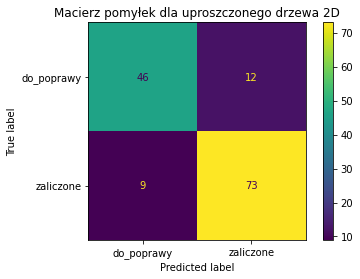

              precision    recall  f1-score   support

  do_poprawy       0.84      0.79      0.81        58
   zaliczone       0.86      0.89      0.87        82

    accuracy                           0.85       140
   macro avg       0.85      0.84      0.84       140
weighted avg       0.85      0.85      0.85       140



In [26]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

y2_pred = model2.predict(X2)

ConfusionMatrixDisplay.from_predictions(y2, y2_pred)
plt.title("Macierz pomyłek dla uproszczonego drzewa 2D")
plt.show()

print(classification_report(y2, y2_pred))

## Macierz pomyłek dla granicy 2D

Ponieważ model 2D został nauczony na całym zbiorze danych,
ta macierz nie służy do uczciwej oceny generalizacji.

Służy tylko do sprawdzenia,
jak dobrze widoczna na wykresie granica 2D rozdziela punkty z danych.

Innymi słowy:

- wykres pokazuje to wizualnie,
- macierz pomyłek pokazuje to liczbowo.

Granice decyzyjne oraz macierz pomyłek dla modelu 2D sugerują,
że model nie tworzy bardzo nieregularnych regionów decyzyjnych.

To może być oznaką,
że model nie jest silnie przeuczony
i powinien zachowywać podobną jakość predykcji na nowych danych.

Nie jest to jednak pełny dowód braku overfittingu,
ponieważ model był uczony na całym zbiorze danych.

**Do uczciwej oceny generalizacji potrzebujemy osobnego zbioru testowego.**

## Co robi kod?

### Wybór dwóch cech

```python
X2 = df[["zadania_pkt", "projekt_pkt"]]
y2 = df["zaliczenie"]
```

Tworzymy uproszczony zbiór danych tylko z dwóch cech,
aby można było narysować model w 2D.

---

### Uczenie drzewa

```python
model2 = DecisionTreeClassifier(max_depth=3, random_state=42)
model2.fit(X2, y2)
```

Model uczy się reguł podziału danych na podstawie dwóch cech.

---

### Tworzenie siatki punktów

```python
xx, yy = np.meshgrid(...)
```

Tworzymy bardzo gęstą siatkę punktów na całej płaszczyźnie.

To są „sztuczne punkty”,
dla których chcemy sprawdzić decyzję modelu.

---

### Predykcja modelu dla całej płaszczyzny

```python
Z = model2.predict(mesh)
```

Model przewiduje klasę dla każdego punktu siatki.

Dzięki temu możemy zobaczyć,
jak model dzieli całą przestrzeń cech.

---

### Rysowanie kolorowych obszarów

```python
plt.contourf(xx, yy, Z_num, alpha=0.25)
```

Kolorujemy obszary,
w których model przewiduje daną klasę.

To właśnie są granice decyzyjne drzewa.

---

### Rysowanie prawdziwych danych

```python
plt.scatter(...)
```

Na wykres nanosimy rzeczywiste obserwacje studentów.

Dzięki temu widzimy:
- gdzie znajdują się dane,
- oraz jak model je rozdziela.

## Po co rysujemy granicę decyzyjną?

Ten wykres pokazuje, jak reguły drzewa dzielą przestrzeń cech.

Ponieważ drzewo zadaje pytania o jedną cechę naraz, np. `zadania_pkt <= próg`,
jego granice decyzyjne są pionowe albo poziome.

Dlatego decyzje drzewa tworzą prostokątne obszary:
w jednym obszarze model przewiduje `zaliczone`,
w innym `do_poprawy`.

Zwróć uwagę: granice drzewa są osiowo-równoległe. To znaczy, że drzewo tnie przestrzeń pytaniami o jedną cechę naraz.

## Mini-ćwiczenie 2: jak `max_depth` zmienia granice decyzyjne?

Porównamy dwa drzewa 2D:

- `max_depth=1` — bardzo proste drzewo,
- `max_depth=3` — bardziej złożone drzewo.

Sprawdź, czy większa głębokość tworzy więcej pionowych i poziomych granic.

In [36]:
max_depth=1
max_depth=2
max_depth=3
max_depth=None

```
Wynik wykonania:

max_depth = 1     -> 2 liście, accuracy na całych danych 0.800
max_depth = 2     -> 4 liście, accuracy na całych danych 0.821
max_depth = 3     -> 7 liści, accuracy na całych danych 0.850
max_depth = None  -> 35 liści, accuracy na całych danych 1.000
```

In [37]:
for depth in [1, 2, 3, None]:
    model_tmp = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model_tmp.fit(X2, y2)
    print("max_depth:", depth)
    print("liczba liści:", model_tmp.get_n_leaves())
    print("accuracy:", round(accuracy_score(y2, model_tmp.predict(X2)), 3))
    print(export_text(model_tmp, feature_names=list(X2.columns)))
    print("-" * 60)

max_depth: 1
liczba liści: 2
accuracy: 0.8
|--- projekt_pkt <= 58.15
|   |--- class: do_poprawy
|--- projekt_pkt >  58.15
|   |--- class: zaliczone

------------------------------------------------------------
max_depth: 2
liczba liści: 4
accuracy: 0.821
|--- projekt_pkt <= 58.15
|   |--- zadania_pkt <= 57.70
|   |   |--- class: do_poprawy
|   |--- zadania_pkt >  57.70
|   |   |--- class: zaliczone
|--- projekt_pkt >  58.15
|   |--- zadania_pkt <= 35.25
|   |   |--- class: do_poprawy
|   |--- zadania_pkt >  35.25
|   |   |--- class: zaliczone

------------------------------------------------------------
max_depth: 3
liczba liści: 7
accuracy: 0.85
|--- projekt_pkt <= 58.15
|   |--- zadania_pkt <= 57.70
|   |   |--- zadania_pkt <= 45.05
|   |   |   |--- class: do_poprawy
|   |   |--- zadania_pkt >  45.05
|   |   |   |--- class: do_poprawy
|   |--- zadania_pkt >  57.70
|   |   |--- zadania_pkt <= 68.80
|   |   |   |--- class: zaliczone
|   |   |--- zadania_pkt >  68.80
|   |   |   |--- cl

In [42]:
def plot_2d_tree_boundary(depth):
    model_tmp = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model_tmp.fit(X2, y2)

    Z = model_tmp.predict(mesh).reshape(xx.shape)
    Z_num = (Z == "zaliczone").astype(int)

    plt.figure(figsize=(7, 5))
    plt.contourf(xx, yy, Z_num, alpha=0.25)

    for label, part in df.groupby("zaliczenie"):
        plt.scatter(
            part["zadania_pkt"],
            part["projekt_pkt"],
            label=label,
            edgecolor="k",
            alpha=0.8
        )

    plt.xlabel("Punkty za zadania")
    plt.ylabel("Punkty za projekt")
    plt.title(f"Granice decyzyjne drzewa 2D, max_depth={depth}")
    plt.legend()
    plt.show()

    print("max_depth:", depth)
    print("liczba liści:", model_tmp.get_n_leaves())
    print("accuracy na całym zbiorze:", round(accuracy_score(y2, model_tmp.predict(X2)), 3))

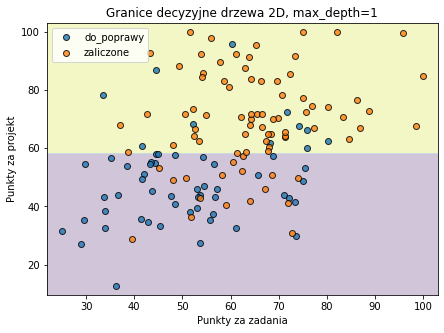

max_depth: 1
liczba liści: 2
accuracy na całym zbiorze: 0.8


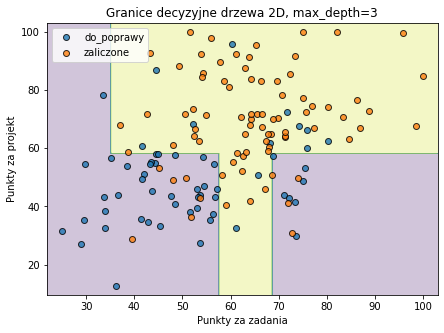

max_depth: 3
liczba liści: 7
accuracy na całym zbiorze: 0.85


In [48]:
plot_2d_tree_boundary(1)
plot_2d_tree_boundary(3)

Dla `max_depth=1` drzewo wykonuje tylko jeden podział.
Na wykresie widzimy więc jedną prostą granicę decyzyjną.

Dla `max_depth=3` drzewo może wykonać kilka kolejnych podziałów.
Granice tworzą więcej prostokątnych obszarów.

Wniosek:
większa głębokość daje modelowi większą elastyczność,
ale zwiększa też ryzyko dopasowania się do szczegółów danych.

# 6. Złożoność drzewa: `max_depth`

Głębsze drzewo zwykle lepiej pamięta dane treningowe, ale może gorzej działać na nowych przykładach.

### Dlaczego `max_depth` jest tak ważne?

`max_depth` ogranicza maksymalną głębokość drzewa.

Małe `max_depth`:

```text
+ prostsze reguły
+ łatwiejsza interpretacja
- czasem zbyt uproszczony model
```

Duże `max_depth`:

```text
+ lepsze dopasowanie do danych treningowych
- większe ryzyko zapamiętania przykładów
- gorsza generalizacja na nowych danych
```

To jest pierwszy moment, w którym wyraźnie widzimy problem **overfittingu**.

In [10]:
rows = []
for depth in [1, 2, 3, 4, 5, None]:
    clf = DecisionTreeClassifier(max_depth=depth, random_state=42)
    clf.fit(X_train, y_train)
    rows.append({
        "max_depth": "None" if depth is None else depth,
        "liczba_lisci": clf.get_n_leaves(),
        "accuracy_train": accuracy_score(y_train, clf.predict(X_train)),
        "accuracy_test": accuracy_score(y_test, clf.predict(X_test))
    })

results = pd.DataFrame(rows)
results

,max_depth,liczba_lisci,accuracy_train,accuracy_test
0,1,2,0.734694,0.857143
1,2,4,0.806122,0.809524
2,3,7,0.846939,0.738095
3,4,11,0.867347,0.714286
4,5,15,0.928571,0.642857
5,None,23,1.000000,0.642857


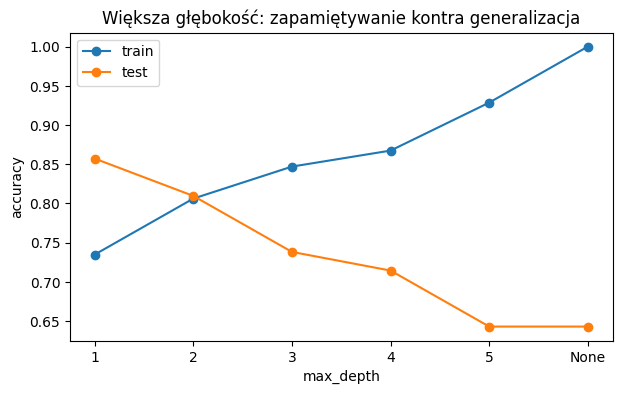

In [11]:
plt.figure(figsize=(7, 4))
plt.plot(results["max_depth"].astype(str), results["accuracy_train"], marker="o", label="train")
plt.plot(results["max_depth"].astype(str), results["accuracy_test"], marker="o", label="test")
plt.xlabel("max_depth")
plt.ylabel("accuracy")
plt.title("Większa głębokość: zapamiętywanie kontra generalizacja")
plt.legend()
plt.show()

Wraz ze wzrostem `max_depth` drzewo dostaje więcej swobody.

Na danych treningowych zwykle działa coraz lepiej,
bo może tworzyć coraz więcej szczegółowych reguł.

Ale po pewnym momencie zaczyna zapamiętywać przypadkowe szczegóły danych treningowych.
Wtedy accuracy na train rośnie, a accuracy na test spada.

To jest klasyczny objaw overfittingu.

Wykres `train` kontra `test` pokazuje klasyczny problem przeuczenia. Głębsze drzewo ma coraz większą swobodę, więc może lepiej zapamiętać zbiór treningowy. Nie oznacza to jednak, że będzie lepsze na nowych danych. **Dlatego ograniczenia typu `max_depth`, `min_samples_leaf` i `min_samples_split` są częścią kontroli złożoności modelu.**

## Mini-ćwiczenie 3: co się stanie, gdy usuniemy najważniejszą cechę?

Usuń z modelu cechę:

```python
"projekt_pkt"

In [53]:
#zamiast X = df[["obecnosc_pct", "zadania_pkt", "projekt_pkt", "quiz_pkt"]] 
# mamyL
X_no_project = df[["obecnosc_pct", "zadania_pkt", "quiz_pkt"]]

In [54]:
X_no_project = df[["obecnosc_pct", "zadania_pkt", "quiz_pkt"]]
y = df["zaliczenie"]

X_train_np, X_test_np, y_train_np, y_test_np = train_test_split(
    X_no_project, y, test_size=0.30, random_state=42, stratify=y
)

model_no_project = DecisionTreeClassifier(max_depth=3, random_state=42)
model_no_project.fit(X_train_np, y_train_np)

print("Accuracy train:", round(accuracy_score(y_train_np, model_no_project.predict(X_train_np)), 3))
print("Accuracy test :", round(accuracy_score(y_test_np, model_no_project.predict(X_test_np)), 3))
print("Liczba liści  :", model_no_project.get_n_leaves())
print()
print(export_text(model_no_project, feature_names=list(X_no_project.columns)))

Accuracy train: 0.796
Accuracy test : 0.619
Liczba liści  : 8

|--- quiz_pkt <= 56.30
|   |--- zadania_pkt <= 48.90
|   |   |--- obecnosc_pct <= 91.70
|   |   |   |--- class: do_poprawy
|   |   |--- obecnosc_pct >  91.70
|   |   |   |--- class: do_poprawy
|   |--- zadania_pkt >  48.90
|   |   |--- zadania_pkt <= 52.30
|   |   |   |--- class: zaliczone
|   |   |--- zadania_pkt >  52.30
|   |   |   |--- class: do_poprawy
|--- quiz_pkt >  56.30
|   |--- zadania_pkt <= 57.30
|   |   |--- zadania_pkt <= 54.15
|   |   |   |--- class: zaliczone
|   |   |--- zadania_pkt >  54.15
|   |   |   |--- class: do_poprawy
|   |--- zadania_pkt >  57.30
|   |   |--- quiz_pkt <= 73.95
|   |   |   |--- class: zaliczone
|   |   |--- quiz_pkt >  73.95
|   |   |   |--- class: zaliczone



In [52]:
X = X = df[["obecnosc_pct", "zadania_pkt", "projekt_pkt", "quiz_pkt"]] 
y = df["zaliczenie"]

X_train_np, X_test_np, y_train_np, y_test_np = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

model_full = DecisionTreeClassifier(max_depth=3, random_state=42)
model_full.fit(X_train_np, y_train_np)

print("Accuracy train:", round(accuracy_score(y_train_np, model_full.predict(X_train_np)), 3))
print("Accuracy test :", round(accuracy_score(y_test_np, model_full.predict(X_test_np)), 3))
print("Liczba liści  :", model_full.get_n_leaves())
print()
print(export_text(model_full, feature_names=list(X.columns)))

Accuracy train: 0.847
Accuracy test : 0.738
Liczba liści  : 7

|--- projekt_pkt <= 62.70
|   |--- quiz_pkt <= 56.30
|   |   |--- quiz_pkt <= 14.95
|   |   |   |--- class: do_poprawy
|   |   |--- quiz_pkt >  14.95
|   |   |   |--- class: do_poprawy
|   |--- quiz_pkt >  56.30
|   |   |--- zadania_pkt <= 36.30
|   |   |   |--- class: do_poprawy
|   |   |--- zadania_pkt >  36.30
|   |   |   |--- class: zaliczone
|--- projekt_pkt >  62.70
|   |--- quiz_pkt <= 63.30
|   |   |--- obecnosc_pct <= 65.15
|   |   |   |--- class: do_poprawy
|   |   |--- obecnosc_pct >  65.15
|   |   |   |--- class: zaliczone
|   |--- quiz_pkt >  63.30
|   |   |--- class: zaliczone



```
Wynik wykonania:

```text
Pełny model:
accuracy train = 0.847
accuracy test  = 0.738
liczba liści   = 7
pierwszy split = projekt_pkt <= 62.70

Model bez projekt_pkt:
accuracy train = 0.796
accuracy test  = 0.619
liczba liści   = 8
pierwszy split = quiz_pkt <= 56.30
```

In [49]:
comparison = pd.DataFrame({
    "model": ["pełny", "bez projekt_pkt"],
    "accuracy_train": [0.847, 0.796],
    "accuracy_test": [0.738, 0.619],
    "liczba_liści": [7, 8],
    "pierwszy_split": ["projekt_pkt <= 62.70", "quiz_pkt <= 56.30"]
})

comparison

,model,accuracy_train,accuracy_test,liczba_liści,pierwszy_split
0,pełny,0.847,0.738,7,projekt_pkt <= 62.70
1,bez projekt_pkt,0.796,0.619,8,quiz_pkt <= 56.30


Po usunięciu `projekt_pkt` model musi oprzeć się na innych cechach.

Widzimy, że pierwszy split zmienia się z:

`projekt_pkt <= 62.70`

na:

`quiz_pkt <= 56.30`

Jednocześnie accuracy test spada z `0.738` do `0.619`.

To sugeruje, że `projekt_pkt` była ważną cechą dla przewidywania zaliczenia.

## Mini-podsumowanie

Ten notebook pokazuje trzy nowe idee:

```text
1. Drzewo samo dobiera progi dla cech liczbowych.
2. Jakość modelu sprawdzamy na danych testowych, nie tylko treningowych.
3. Głębsze drzewo nie zawsze jest lepsze, bo może się przeuczyć.
```

To jest naturalny most między prostą intuicją drzewa a realnym procesem uczenia modelu.

# APPENDIX A

## Podstawowe pojęcia: TP, TN, FP, FN

W klasyfikacji binarnej interesują nas cztery sytuacje:

### True Positive (TP)

Model przewidział `zaliczone`
i rzeczywiście było `zaliczone`.

```text
model: zaliczone
prawda: zaliczone
```

---

### True Negative (TN)

Model przewidział `do_poprawy`
i rzeczywiście było `do_poprawy`.

```text
model: do_poprawy
prawda: do_poprawy
```

---

### False Positive (FP)

Model przewidział `zaliczone`,
ale naprawdę było `do_poprawy`.

```text
model: zaliczone
prawda: do_poprawy
```

To jest „fałszywy alarm pozytywny”.

---

### False Negative (FN)

Model przewidział `do_poprawy`,
ale naprawdę było `zaliczone`.

```text
model: do_poprawy
prawda: zaliczone
```

---

## Accuracy

Accuracy mówi,
jaki procent wszystkich predykcji był poprawny:

$$
Accuracy =
\frac{TP + TN}{TP + TN + FP + FN}
$$

---

## Precision

Spośród wszystkich przewidzianych pozytywów:

> ile było naprawdę pozytywnych?

$$
Precision =
\frac{TP}{TP + FP}
$$

---

## Recall (Sensitivity)

Spośród wszystkich prawdziwych pozytywów:

> ile model wykrył?

$$
Recall =
\frac{TP}{TP + FN}
$$

---

## F1-score

Średnia harmoniczna precision i recall:

$$
F1 =
2 \cdot
\frac{Precision \cdot Recall}
{Precision + Recall}
$$

# APPENDIX B